Form des Datensatzes:
Zeilen und Spalten: (6019, 13)

--------------------------------
Erste 5 Zeilen:
--------------------------------


,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74



--------------------------------
Spaltennamen:
--------------------------------
['Name', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats', 'New_Price', 'Price']

--------------------------------
Datentypen und fehlende Werte:
--------------------------------


,Datentyp,Fehlende Werte,Fehlende Werte in %
Name,object,0,0.00
Location,object,0,0.00
Year,int64,0,0.00
Kilometers_Driven,int64,0,0.00
Fuel_Type,object,0,0.00
Transmission,object,0,0.00
Owner_Type,object,0,0.00
Mileage,object,2,0.03
Engine,object,36,0.60
Power,object,36,0.60



--------------------------------
Statistik der numerischen Spalten:
--------------------------------


,Year,Kilometers_Driven,Seats,Price
count,6019.000000,6.019000e+03,5977.000000,6019.000000
mean,2013.358199,5.873838e+04,5.278735,9.479468
std,3.269742,9.126884e+04,0.808840,11.187917
min,1998.000000,1.710000e+02,0.000000,0.440000
25%,2011.000000,3.400000e+04,5.000000,3.500000
50%,2014.000000,5.300000e+04,5.000000,5.640000
75%,2016.000000,7.300000e+04,5.000000,9.950000
max,2019.000000,6.500000e+06,10.000000,160.000000



--------------------------------
Häufigkeiten wichtiger Kategorien:
--------------------------------

Fuel_Type:
Fuel_Type
Diesel      3205
Petrol      2746
CNG           56
LPG           10
Electric       2
Name: count, dtype: int64

Transmission:
Transmission
Manual       4299
Automatic    1720
Name: count, dtype: int64

Owner_Type:
Owner_Type
First             4929
Second             968
Third              113
Fourth & Above       9
Name: count, dtype: int64


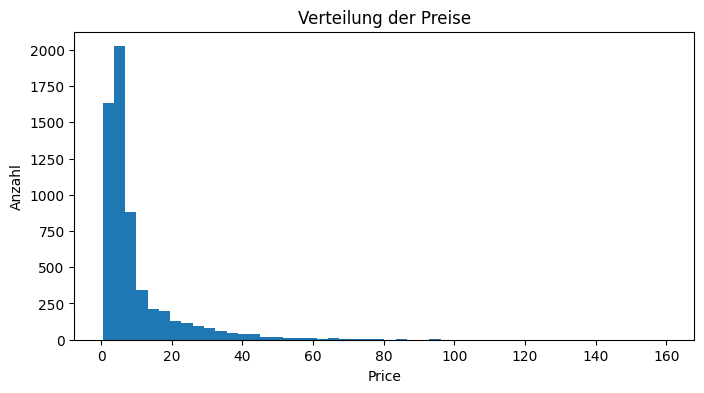

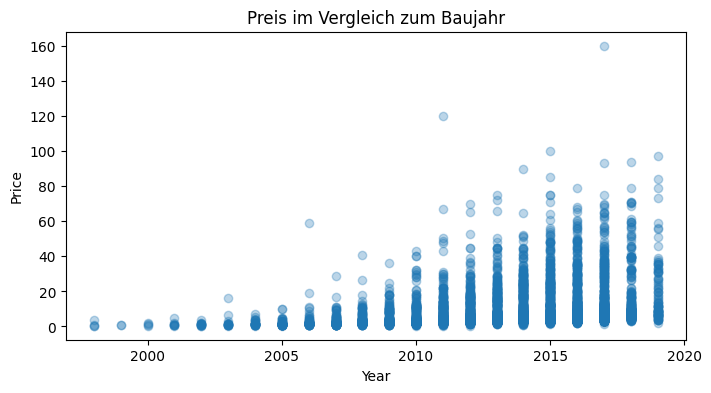

In [1]:
# ==========================================
# SCHRITT 1: DATEN LADEN + ERSTER ÜBERBLICK
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# Datenquelle 1: Gebrauchtwagen-Datensatz
url = "https://raw.githubusercontent.com/sagnikghoshcr7/Car-Price-Prediction/master/data/dataset.csv"

# CSV-Datei laden
df = pd.read_csv(url)

# Falls eine unnötige Index-Spalte vorhanden ist, entfernen
df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")], errors="ignore")

# Form des Datensatzes anzeigen
print("Form des Datensatzes:")
print("Zeilen und Spalten:", df.shape)

print("\n--------------------------------")
print("Erste 5 Zeilen:")
print("--------------------------------")
display(df.head())

print("\n--------------------------------")
print("Spaltennamen:")
print("--------------------------------")
print(df.columns.tolist())

print("\n--------------------------------")
print("Datentypen und fehlende Werte:")
print("--------------------------------")

info = pd.DataFrame({
    "Datentyp": df.dtypes.astype(str),
    "Fehlende Werte": df.isna().sum(),
    "Fehlende Werte in %": (df.isna().mean() * 100).round(2)
})

display(info)

print("\n--------------------------------")
print("Statistik der numerischen Spalten:")
print("--------------------------------")
display(df.describe())

print("\n--------------------------------")
print("Häufigkeiten wichtiger Kategorien:")
print("--------------------------------")

for col in ["Fuel_Type", "Transmission", "Owner_Type"]:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].value_counts())

# Erste einfache Grafiken
plt.figure(figsize=(8, 4))
df["Price"].plot(kind="hist", bins=50)
plt.title("Verteilung der Preise")
plt.xlabel("Price")
plt.ylabel("Anzahl")
plt.show()

plt.figure(figsize=(8, 4))
plt.scatter(df["Year"], df["Price"], alpha=0.3)
plt.title("Preis im Vergleich zum Baujahr")
plt.xlabel("Year")
plt.ylabel("Price")
plt.show()

Startform: (6019, 13)
Referenzjahr für Car_Age: 2020
Entfernte Zeilen wegen extremen Kilometern: 4
Seats: fehlende Werte mit Median 5.0 aufgefüllt
Mileage_num: fehlende Werte mit Median 18.15 aufgefüllt
Engine_num: fehlende Werte mit Median 1493.0 aufgefüllt
Power_num: fehlende Werte mit Median 97.7 aufgefüllt

--------------------------------
Neue Form nach Cleaning:
--------------------------------
(6015, 14)

--------------------------------
Spalten nach Cleaning:
--------------------------------
['Name', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Seats', 'Price', 'Mileage_num', 'Engine_num', 'Power_num', 'Brand', 'Car_Age']

--------------------------------
Fehlende Werte nach Cleaning:
--------------------------------


,Fehlende Werte
Name,0
Location,0
Year,0
Kilometers_Driven,0
Fuel_Type,0
Transmission,0
Owner_Type,0
Seats,0
Price,0
Mileage_num,0



--------------------------------
Erste 5 Zeilen nach Cleaning:
--------------------------------


,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Seats,Price,Mileage_num,Engine_num,Power_num,Brand,Car_Age
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,5.0,1.75,26.60,998.0,58.16,Maruti,10
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,5.0,12.50,19.67,1582.0,126.20,Hyundai,5
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,5.0,4.50,18.20,1199.0,88.70,Honda,9
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,7.0,6.00,20.77,1248.0,88.76,Maruti,8
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,5.0,17.74,15.20,1968.0,140.80,Audi,7



--------------------------------
Statistik der neuen Zahlen-Spalten:
--------------------------------


,Mileage_num,Engine_num,Power_num,Car_Age,Price
count,6015.000000,6015.000000,6015.000000,6015.000000,6015.000000
mean,18.134362,1620.297423,112.861932,6.641563,9.472289
std,4.582747,599.531965,53.265386,3.270003,11.168245
min,0.000000,72.000000,34.200000,1.000000,0.440000
25%,15.170000,1198.000000,78.000000,4.000000,3.500000
50%,18.150000,1493.000000,97.700000,6.000000,5.640000
75%,21.100000,1969.000000,138.030000,9.000000,9.950000
max,33.540000,5998.000000,560.000000,22.000000,160.000000


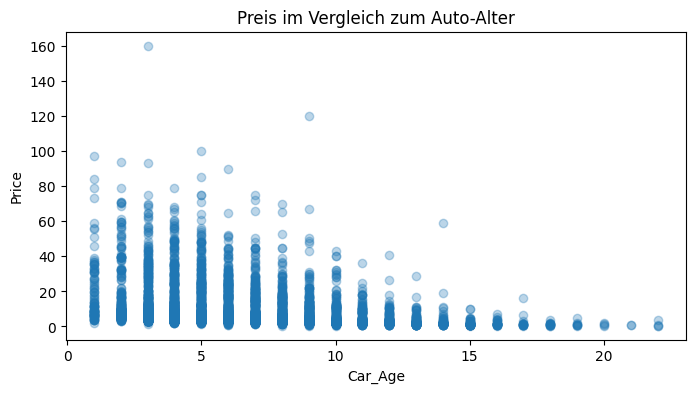

Fertig. Die saubere Datei wurde gespeichert als: cleaned_cars_step3.csv


In [2]:
# ==========================================
# SCHRITT 3: DATEN PUTZEN + FEATURES BAUEN
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from IPython.display import display

# Daten nochmals frisch laden, damit diese Zelle unabhängig funktioniert
url = "https://raw.githubusercontent.com/sagnikghoshcr7/Car-Price-Prediction/master/data/dataset.csv"
df = pd.read_csv(url)

# Unnötige Index-Spalte entfernen, falls vorhanden
df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")], errors="ignore")

# Kopie erstellen, damit das Original df erhalten bleibt
df_clean = df.copy()

print("Startform:", df_clean.shape)

# ------------------------------------------------
# 1. Funktion: Zahl aus Text herausziehen
# Beispiel: "998 CC" -> 998
# Beispiel: "58.16 bhp" -> 58.16
# ------------------------------------------------

def extract_number(value):
    if pd.isna(value):
        return np.nan

    value = str(value)

    # Im Datensatz gibt es z. B. "null bhp" -> das ist keine Zahl
    if "null" in value.lower():
        return np.nan

    # Erste Zahl im Text suchen
    match = re.search(r"[-+]?\d*\.?\d+", value)

    if match:
        return float(match.group())
    else:
        return np.nan

# ------------------------------------------------
# 2. Neue numerische Spalten erstellen
# ------------------------------------------------

df_clean["Mileage_num"] = df_clean["Mileage"].apply(extract_number)
df_clean["Engine_num"] = df_clean["Engine"].apply(extract_number)
df_clean["Power_num"] = df_clean["Power"].apply(extract_number)

# ------------------------------------------------
# 3. Marke aus dem Namen ziehen
# Beispiel: "Maruti Wagon R LXI CNG" -> "Maruti"
# ------------------------------------------------

df_clean["Brand"] = df_clean["Name"].astype(str).str.split().str[0]

# ------------------------------------------------
# 4. Auto-Alter berechnen
# Wir nehmen Referenzjahr = max. Jahr im Datensatz + 1
# Hier also ungefähr: 2019 + 1 = 2020
# ------------------------------------------------

reference_year = df_clean["Year"].max() + 1
df_clean["Car_Age"] = reference_year - df_clean["Year"]

print("Referenzjahr für Car_Age:", reference_year)

# ------------------------------------------------
# 5. Unlogische Werte behandeln
# ------------------------------------------------

# Seats = 0 ist unlogisch -> als fehlend markieren
df_clean.loc[df_clean["Seats"] == 0, "Seats"] = np.nan

# Extrem unrealistische Kilometer entfernen
# 6.5 Millionen km ist sehr wahrscheinlich ein Ausreisser
before_rows = df_clean.shape[0]
df_clean = df_clean[df_clean["Kilometers_Driven"] <= 500000].copy()
after_rows = df_clean.shape[0]

print("Entfernte Zeilen wegen extremen Kilometern:", before_rows - after_rows)

# ------------------------------------------------
# 6. New_Price entfernen
# Grund: über 86% fehlende Werte
# ------------------------------------------------

df_clean = df_clean.drop(columns=["New_Price"], errors="ignore")

# ------------------------------------------------
# 7. Original-Textspalten entfernen, weil wir neue Zahlen-Spalten haben
# ------------------------------------------------

df_clean = df_clean.drop(columns=["Mileage", "Engine", "Power"], errors="ignore")

# ------------------------------------------------
# 8. Fehlende Werte auffüllen
# ------------------------------------------------

# Numerische Spalten: mit Median auffüllen
numeric_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()

for col in numeric_cols:
    if df_clean[col].isna().sum() > 0:
        median_value = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_value)
        print(f"{col}: fehlende Werte mit Median {median_value} aufgefüllt")

# Kategorische Spalten: mit häufigstem Wert auffüllen
categorical_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()

for col in categorical_cols:
    if df_clean[col].isna().sum() > 0:
        mode_value = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_value)
        print(f"{col}: fehlende Werte mit häufigstem Wert '{mode_value}' aufgefüllt")

# ------------------------------------------------
# 9. Ergebnis prüfen
# ------------------------------------------------

print("\n--------------------------------")
print("Neue Form nach Cleaning:")
print("--------------------------------")
print(df_clean.shape)

print("\n--------------------------------")
print("Spalten nach Cleaning:")
print("--------------------------------")
print(df_clean.columns.tolist())

print("\n--------------------------------")
print("Fehlende Werte nach Cleaning:")
print("--------------------------------")
display(df_clean.isna().sum().to_frame("Fehlende Werte"))

print("\n--------------------------------")
print("Erste 5 Zeilen nach Cleaning:")
print("--------------------------------")
display(df_clean.head())

print("\n--------------------------------")
print("Statistik der neuen Zahlen-Spalten:")
print("--------------------------------")
display(df_clean[["Mileage_num", "Engine_num", "Power_num", "Car_Age", "Price"]].describe())

# ------------------------------------------------
# 10. Kleine Grafik nach Cleaning
# ------------------------------------------------

plt.figure(figsize=(8, 4))
plt.scatter(df_clean["Car_Age"], df_clean["Price"], alpha=0.3)
plt.title("Preis im Vergleich zum Auto-Alter")
plt.xlabel("Car_Age")
plt.ylabel("Price")
plt.show()

# Saubere Datei speichern
df_clean.to_csv("cleaned_cars_step3.csv", index=False)

print("Fertig. Die saubere Datei wurde gespeichert als: cleaned_cars_step3.csv")

In [3]:
# ==========================================
# SCHRITT 4: ZWEITE DATENQUELLE EINBAUEN
# ==========================================

import pandas as pd
import numpy as np
from IPython.display import display

# Falls df_clean aus der vorherigen Zelle noch existiert, verwenden wir es.
# Falls nicht, laden wir die gespeicherte Datei.
try:
    df_clean
    print("df_clean wurde aus der vorherigen Zelle gefunden.")
except NameError:
    print("df_clean wurde nicht gefunden. Datei wird geladen.")
    df_clean = pd.read_csv("cleaned_cars_step3.csv")

# ------------------------------------------------
# Zweite Datenquelle:
# Öffentliche Referenztabelle zu Treibstoff-/CO2-Faktoren
#
# Quelle für die Werte:
# Energy Saving Trust / DESNZ 2023 GHG factors
#
# Wichtig:
# Diese Tabelle ist unsere zweite Datenquelle.
# Sie wird über Fuel_Type mit dem Auto-Datensatz verbunden.
# ------------------------------------------------

fuel_reference = pd.DataFrame({
    "Fuel_Type": ["Petrol", "Diesel", "CNG", "LPG", "Electric"],
    "fuel_unit": ["litre", "litre", "kg", "litre", "kWh"],
    "kg_co2e_per_unit": [2.10, 2.51, 2.5625, 1.56, 0.212],
    "kg_co2e_per_kwh": [0.22, 0.24, 0.18, 0.21, 0.19],
    "kwh_per_unit": [9.545455, 10.45833, 14.23611, 7.428571, 1.0]
})

print("Zweite Datenquelle: Fuel/CO2 Reference Table")
display(fuel_reference)

# ------------------------------------------------
# Join: Auto-Daten + Treibstoffdaten verbinden
# ------------------------------------------------

df_model = df_clean.merge(fuel_reference, on="Fuel_Type", how="left")

# Prüfen, ob alle Fuel Types verbunden wurden
print("\nFehlende Werte nach dem Join:")
display(df_model[["Fuel_Type", "fuel_unit", "kg_co2e_per_unit", "kg_co2e_per_kwh", "kwh_per_unit"]].isna().sum().to_frame("Fehlende Werte"))

print("\nAnzahl Autos pro Fuel Type nach dem Join:")
display(df_model["Fuel_Type"].value_counts().to_frame("Anzahl"))

# ------------------------------------------------
# Neues Feature bauen:
# geschätzte CO2e-Emission pro Kilometer
#
# Idee:
# Wenn ein Auto z.B. 20 km pro Liter fährt
# und 1 Liter 2.10 kg CO2e verursacht,
# dann ist der grobe Wert:
# 2.10 / 20 = 0.105 kg CO2e pro km
# ------------------------------------------------

df_model["estimated_kg_co2e_per_km"] = np.where(
    df_model["Mileage_num"] > 0,
    df_model["kg_co2e_per_unit"] / df_model["Mileage_num"],
    np.nan
)

# Falls bei Electric oder komischen Mileage-Werten etwas fehlt, füllen wir mit Median
median_co2_per_km = df_model["estimated_kg_co2e_per_km"].median()
df_model["estimated_kg_co2e_per_km"] = df_model["estimated_kg_co2e_per_km"].fillna(median_co2_per_km)

print("\nMedian estimated_kg_co2e_per_km:", median_co2_per_km)

# ------------------------------------------------
# Ergebnis anschauen
# ------------------------------------------------

print("\nNeue Form nach zweiter Datenquelle:")
print(df_model.shape)

print("\nNeue Spalten aus Datenquelle 2:")
display(df_model[[
    "Fuel_Type",
    "Mileage_num",
    "fuel_unit",
    "kg_co2e_per_unit",
    "kg_co2e_per_kwh",
    "kwh_per_unit",
    "estimated_kg_co2e_per_km",
    "Price"
]].head(10))

print("\nStatistik des neuen CO2-Features:")
display(df_model[["kg_co2e_per_unit", "kg_co2e_per_kwh", "kwh_per_unit", "estimated_kg_co2e_per_km"]].describe())

# Speichern für nächsten Schritt
df_model.to_csv("cars_with_fuel_source_step4.csv", index=False)

print("\nFertig. Datei gespeichert als: cars_with_fuel_source_step4.csv")

df_clean wurde aus der vorherigen Zelle gefunden.
Zweite Datenquelle: Fuel/CO2 Reference Table


,Fuel_Type,fuel_unit,kg_co2e_per_unit,kg_co2e_per_kwh,kwh_per_unit
0,Petrol,litre,2.1000,0.22,9.545455
1,Diesel,litre,2.5100,0.24,10.458330
2,CNG,kg,2.5625,0.18,14.236110
3,LPG,litre,1.5600,0.21,7.428571
4,Electric,kWh,0.2120,0.19,1.000000



Fehlende Werte nach dem Join:


,Fehlende Werte
Fuel_Type,0
fuel_unit,0
kg_co2e_per_unit,0
kg_co2e_per_kwh,0
kwh_per_unit,0



Anzahl Autos pro Fuel Type nach dem Join:


...


Median estimated_kg_co2e_per_km: 0.12352941176470589

Neue Form nach zweiter Datenquelle:
(6015, 19)

Neue Spalten aus Datenquelle 2:


,Fuel_Type,Mileage_num,fuel_unit,kg_co2e_per_unit,kg_co2e_per_kwh,kwh_per_unit,estimated_kg_co2e_per_km,Price
0,CNG,26.60,kg,2.5625,0.18,14.236110,0.096335,1.75
1,Diesel,19.67,litre,2.5100,0.24,10.458330,0.127605,12.50
2,Petrol,18.20,litre,2.1000,0.22,9.545455,0.115385,4.50
3,Diesel,20.77,litre,2.5100,0.24,10.458330,0.120847,6.00
4,Diesel,15.20,litre,2.5100,0.24,10.458330,0.165132,17.74
5,LPG,21.10,litre,1.5600,0.21,7.428571,0.073934,2.35
6,Diesel,23.08,litre,2.5100,0.24,10.458330,0.108752,3.50
7,Diesel,11.36,litre,2.5100,0.24,10.458330,0.220951,17.50
8,Diesel,20.54,litre,2.5100,0.24,10.458330,0.122201,5.20
9,Diesel,22.30,litre,2.5100,0.24,10.458330,0.112556,1.95



Statistik des neuen CO2-Features:


,kg_co2e_per_unit,kg_co2e_per_kwh,kwh_per_unit,estimated_kg_co2e_per_km
count,6015.000000,6015.000000,6015.000000,6015.000000
mean,2.321038,0.230248,10.068721,0.133479
std,0.210468,0.011104,0.637535,0.035149
min,0.212000,0.180000,1.000000,0.011680
25%,2.100000,0.220000,9.545455,0.109948
50%,2.510000,0.240000,10.458330,0.123529
75%,2.510000,0.240000,10.458330,0.150000
max,2.562500,0.240000,14.236110,0.334667



Fertig. Datei gespeichert als: cars_with_fuel_source_step4.csv


In [4]:
# ==========================================
# SCHRITT 5: MACHINE LEARNING MODELLE TRAINIEREN
# ==========================================

import pandas as pd
import numpy as np
import joblib
import json

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------------------------
# 1. Daten laden
# ------------------------------------------------

try:
    df_model
    print("df_model wurde aus der vorherigen Zelle gefunden.")
except NameError:
    print("df_model wurde nicht gefunden. Datei wird geladen.")
    df_model = pd.read_csv("cars_with_fuel_source_step4.csv")

print("Form der Daten:", df_model.shape)

# ------------------------------------------------
# 2. Spalten auswählen
# ------------------------------------------------

# Diese Spalten verwenden wir NICHT als Input:
# Name = zu spezifisch
# Price = Zielwert, den wir vorhersagen wollen
# fuel_unit = Textinfo, nicht nötig fürs Modell
drop_cols = ["Name", "Price", "fuel_unit"]

X = df_model.drop(columns=drop_cols, errors="ignore")
y = df_model["Price"]

print("\nInput-Spalten für das Modell:")
print(X.columns.tolist())

print("\nZielspalte:")
print("Price")

# ------------------------------------------------
# 3. Numerische und kategorische Spalten erkennen
# ------------------------------------------------

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("\nNumerische Spalten:")
print(numeric_features)

print("\nKategorische Spalten:")
print(categorical_features)

# ------------------------------------------------
# 4. Train-Test-Split
# ------------------------------------------------
# 80% Training, 20% Test
# Das Modell lernt auf Training und wird auf Test geprüft.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("\nTrainingsdaten:", X_train.shape)
print("Testdaten:", X_test.shape)

# ------------------------------------------------
# 5. Preprocessing vorbereiten
# ------------------------------------------------
# Zahlen werden skaliert.
# Kategorien werden in 0/1-Spalten umgewandelt.

numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# ------------------------------------------------
# 6. Zwei Modelle definieren
# ------------------------------------------------

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

results = []
trained_pipelines = {}

# ------------------------------------------------
# 7. Modelle trainieren und bewerten
# ------------------------------------------------

for model_name, model in models.items():
    print(f"\nTrainiere Modell: {model_name}")

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Modell": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    trained_pipelines[model_name] = pipeline

# ------------------------------------------------
# 8. Vergleich anzeigen
# ------------------------------------------------

results_df = pd.DataFrame(results).sort_values(by="RMSE")

print("\n================================")
print("MODELLVERGLEICH")
print("================================")
display(results_df)

# ------------------------------------------------
# 9. Bestes Modell auswählen
# ------------------------------------------------

best_model_name = results_df.iloc[0]["Modell"]
best_pipeline = trained_pipelines[best_model_name]

print(f"\nBestes Modell nach RMSE: {best_model_name}")

# ------------------------------------------------
# 10. Fehleranalyse für bestes Modell
# ------------------------------------------------

y_pred_best = best_pipeline.predict(X_test)

error_df = X_test.copy()
error_df["Actual_Price"] = y_test.values
error_df["Predicted_Price"] = y_pred_best
error_df["Absolute_Error"] = abs(error_df["Actual_Price"] - error_df["Predicted_Price"])

print("\n================================")
print("GRÖSSTE FEHLER DES BESTEN MODELLS")
print("================================")

display(
    error_df.sort_values(by="Absolute_Error", ascending=False)
    .head(10)[[
        "Brand",
        "Year",
        "Car_Age",
        "Kilometers_Driven",
        "Fuel_Type",
        "Transmission",
        "Actual_Price",
        "Predicted_Price",
        "Absolute_Error"
    ]]
)

print("\n================================")
print("FEHLER NACH PREISGRUPPEN")
print("================================")

error_df["Price_Group"] = pd.cut(
    error_df["Actual_Price"],
    bins=[0, 5, 10, 20, 50, 200],
    labels=["0-5", "5-10", "10-20", "20-50", "50+"]
)

price_group_errors = error_df.groupby("Price_Group", observed=False)["Absolute_Error"].mean().reset_index()
display(price_group_errors)

# ------------------------------------------------
# 11. Bestes Modell speichern
# ------------------------------------------------

joblib.dump(best_pipeline, "best_car_price_model.joblib")

with open("model_features.json", "w") as f:
    json.dump({
        "features": X.columns.tolist(),
        "numeric_features": numeric_features,
        "categorical_features": categorical_features,
        "best_model": best_model_name
    }, f, indent=4)

print("\nFertig.")
print("Gespeichertes Modell: best_car_price_model.joblib")
print("Gespeicherte Feature-Infos: model_features.json")

df_model wurde aus der vorherigen Zelle gefunden.
Form der Daten: (6015, 19)

Input-Spalten für das Modell:
['Location', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Seats', 'Mileage_num', 'Engine_num', 'Power_num', 'Brand', 'Car_Age', 'kg_co2e_per_unit', 'kg_co2e_per_kwh', 'kwh_per_unit', 'estimated_kg_co2e_per_km']

Zielspalte:
Price

Numerische Spalten:
['Year', 'Kilometers_Driven', 'Seats', 'Mileage_num', 'Engine_num', 'Power_num', 'Car_Age', 'kg_co2e_per_unit', 'kg_co2e_per_kwh', 'kwh_per_unit', 'estimated_kg_co2e_per_km']

Kategorische Spalten:
['Location', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Brand']

Trainingsdaten: (4812, 16)
Testdaten: (1203, 16)

Trainiere Modell: Linear Regression

Trainiere Modell: Random Forest

MODELLVERGLEICH


,Modell,MAE,RMSE,R2
1,Random Forest,1.402996,2.952535,0.924481
0,Linear Regression,2.900384,4.827344,0.798124



Bestes Modell nach RMSE: Random Forest

GRÖSSTE FEHLER DES BESTEN MODELLS


,Brand,Year,Car_Age,Kilometers_Driven,Fuel_Type,Transmission,Actual_Price,Predicted_Price,Absolute_Error
3262,Mercedes-Benz,2015,5,7501,Petrol,Automatic,48.00,72.28135,24.28135
5599,Porsche,2013,7,36400,Diesel,Automatic,72.00,48.47500,23.52500
5337,Porsche,2016,4,65003,Diesel,Automatic,67.83,46.46625,21.36375
1671,Audi,2015,5,11964,Diesel,Automatic,32.95,53.76965,20.81965
3055,BMW,2019,1,87000,Diesel,Automatic,6.67,26.42450,19.75450
354,Jaguar,2017,3,21000,Diesel,Automatic,52.00,32.92700,19.07300
4812,BMW,2006,14,48000,Petrol,Automatic,6.99,24.70135,17.71135
584,Audi,2014,6,79926,Diesel,Automatic,29.77,47.33945,17.56945
2302,Porsche,2011,9,8000,Petrol,Automatic,43.00,26.11965,16.88035
2505,Mercedes-Benz,2018,2,11000,Diesel,Automatic,56.50,39.99210,16.50790



FEHLER NACH PREISGRUPPEN


,Price_Group,Absolute_Error
0,0-5,0.516631
1,5-10,0.967508
2,10-20,2.169684
3,20-50,4.177711
4,50+,9.147375



Fertig.
Gespeichertes Modell: best_car_price_model.joblib
Gespeicherte Feature-Infos: model_features.json


In [6]:
# ==========================================
# SCHRITT 6 FIX: NLP OHNE PIPELINE
# ==========================================

import sys
import subprocess
import pkgutil

# Falls nötig installieren
if pkgutil.find_loader("transformers") is None:
    print("Installiere transformers und sentencepiece...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "transformers", "sentencepiece"])

import pandas as pd
import numpy as np
import joblib
from IPython.display import display

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# ------------------------------------------------
# 1. ML-Modell und Daten laden
# ------------------------------------------------

try:
    best_pipeline
    X_test
    y_test
    print("ML-Modell und Testdaten wurden aus der vorherigen Zelle gefunden.")
except NameError:
    print("ML-Modell oder Testdaten wurden nicht gefunden. Dateien werden geladen.")
    best_pipeline = joblib.load("best_car_price_model.joblib")
    df_model = pd.read_csv("cars_with_fuel_source_step4.csv")
    X = df_model.drop(columns=["Name", "Price", "fuel_unit"], errors="ignore")
    y = df_model["Price"]

    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

# ------------------------------------------------
# 2. Kostenloses Sprachmodell direkt laden
# ------------------------------------------------

print("Lade kostenloses Sprachmodell. Das kann 1-2 Minuten dauern...")

model_name = "google/flan-t5-small"

tokenizer = AutoTokenizer.from_pretrained(model_name)
language_model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

print("Sprachmodell geladen.")

# ------------------------------------------------
# 3. Autodaten als Text zusammenfassen
# ------------------------------------------------

def get_car_summary(row, predicted_price):
    return f"""
Brand: {row.get('Brand')}
Year: {row.get('Year')}
Car age: {row.get('Car_Age')}
Kilometers driven: {row.get('Kilometers_Driven')}
Fuel type: {row.get('Fuel_Type')}
Transmission: {row.get('Transmission')}
Owner type: {row.get('Owner_Type')}
Mileage: {row.get('Mileage_num')}
Engine: {row.get('Engine_num')}
Power: {row.get('Power_num')}
Estimated CO2 per km: {row.get('estimated_kg_co2e_per_km')}
Predicted used car price: {predicted_price:.2f}
"""

# ------------------------------------------------
# 4. Zwei Prompt-Varianten bauen
# ------------------------------------------------

def build_prompt(row, predicted_price, variant="simple"):
    car_summary = get_car_summary(row, predicted_price)

    if variant == "simple":
        return f"""
Explain in simple English why this used car has this predicted price.
Mention the most important factors.

Car data:
{car_summary}
"""

    elif variant == "structured":
        return f"""
You are a used car price assistant.
Explain the predicted price in clear English.

Use this structure:
1. Main reason for the price
2. Factors increasing the price
3. Factors decreasing the price
4. Short buying advice

Car data:
{car_summary}
"""

    else:
        raise ValueError("Unknown prompt variant")

# ------------------------------------------------
# 5. Text generieren ohne pipeline
# ------------------------------------------------

def generate_explanation(row, predicted_price, variant="simple"):
    prompt = build_prompt(row, predicted_price, variant)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    outputs = language_model.generate(
        **inputs,
        max_new_tokens=120,
        num_beams=4,
        early_stopping=True
    )

    explanation = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return explanation

# ------------------------------------------------
# 6. Test mit 3 Beispielautos
# ------------------------------------------------

sample_indices = [0, 1, 2]
comparison_rows = []

for i in sample_indices:
    row = X_test.iloc[i]
    actual_price = y_test.iloc[i]
    predicted_price = best_pipeline.predict(pd.DataFrame([row]))[0]

    simple_explanation = generate_explanation(row, predicted_price, variant="simple")
    structured_explanation = generate_explanation(row, predicted_price, variant="structured")

    comparison_rows.append({
        "Brand": row.get("Brand"),
        "Year": row.get("Year"),
        "Fuel_Type": row.get("Fuel_Type"),
        "Transmission": row.get("Transmission"),
        "Actual_Price": actual_price,
        "Predicted_Price": round(predicted_price, 2),
        "Prompt_A_simple": simple_explanation,
        "Prompt_B_structured": structured_explanation
    })

comparison_df = pd.DataFrame(comparison_rows)

print("Vergleich von zwei Prompt-Varianten:")
display(comparison_df)

# ------------------------------------------------
# 7. Speichern für Dokumentation
# ------------------------------------------------

comparison_df.to_csv("nlp_prompt_comparison_step6.csv", index=False)

print("Fertig. Prompt-Vergleich gespeichert als: nlp_prompt_comparison_step6.csv")

/tmp/ipykernel_1141/2440839560.py:10: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
  if pkgutil.find_loader("transformers") is None:


ML-Modell und Testdaten wurden aus der vorherigen Zelle gefunden.
Lade kostenloses Sprachmodell. Das kann 1-2 Minuten dauern...


tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Sprachmodell geladen.
Vergleich von zwei Prompt-Varianten:


,Brand,Year,Fuel_Type,Transmission,Actual_Price,Predicted_Price,Prompt_A_simple,Prompt_B_structured
0,Tata,2008,Diesel,Manual,1.25,1.33,Tata is a car that has a price range of 1.33.,3. 4. Short buying advice
1,Hyundai,2010,Diesel,Manual,2.70,3.35,Price of the used car is 3.35.,3.35
2,Maruti,2013,Diesel,Manual,3.38,4.26,Price of the used car is 4.26.,2. Factors increasing the price 3. Factors dec...


Fertig. Prompt-Vergleich gespeichert als: nlp_prompt_comparison_step6.csv


In [7]:
# ==========================================
# SCHRITT 6B: BESSERE NLP-ERKLÄRUNG + FALLBACK
# ==========================================

import pandas as pd
import numpy as np
import joblib
from IPython.display import display

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# ------------------------------------------------
# 1. Sicherstellen, dass Modell und Daten da sind
# ------------------------------------------------

try:
    best_pipeline
    X_test
    y_test
    print("ML-Modell und Testdaten wurden gefunden.")
except NameError:
    print("ML-Modell oder Testdaten wurden nicht gefunden. Dateien werden geladen.")
    best_pipeline = joblib.load("best_car_price_model.joblib")
    df_model = pd.read_csv("cars_with_fuel_source_step4.csv")
    X = df_model.drop(columns=["Name", "Price", "fuel_unit"], errors="ignore")
    y = df_model["Price"]

    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

# ------------------------------------------------
# 2. Sprachmodell laden
# ------------------------------------------------

try:
    tokenizer
    language_model
    print("Sprachmodell wurde aus vorheriger Zelle gefunden.")
except NameError:
    print("Lade Sprachmodell erneut...")
    model_name = "google/flan-t5-small"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    language_model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
    print("Sprachmodell geladen.")

# ------------------------------------------------
# 3. Einfache Faktor-Analyse
# ------------------------------------------------

def analyse_car_factors(row, predicted_price):
    factors_up = []
    factors_down = []

    age = row.get("Car_Age")
    km = row.get("Kilometers_Driven")
    power = row.get("Power_num")
    transmission = row.get("Transmission")
    owner = row.get("Owner_Type")
    brand = row.get("Brand")
    fuel = row.get("Fuel_Type")

    # Alter
    if age <= 5:
        factors_up.append("the car is relatively new")
    elif age >= 10:
        factors_down.append("the car is older")

    # Kilometer
    if km <= 40000:
        factors_up.append("the mileage is low")
    elif km >= 90000:
        factors_down.append("the mileage is high")

    # Power
    if power >= 120:
        factors_up.append("the engine power is strong")
    elif power <= 75:
        factors_down.append("the engine power is modest")

    # Transmission
    if transmission == "Automatic":
        factors_up.append("automatic transmission can increase market value")

    # Owner type
    if owner == "First":
        factors_up.append("it is a first-owner car")
    else:
        factors_down.append("it had previous owners")

    # Brand
    if brand in ["Mercedes-Benz", "BMW", "Audi", "Porsche", "Jaguar", "Land"]:
        factors_up.append("the brand is positioned as premium")

    # Fuel
    if fuel == "Diesel":
        factors_up.append("diesel cars can be valued higher for long-distance use")
    elif fuel in ["CNG", "LPG"]:
        factors_down.append("alternative fuel types may have a smaller market")

    if len(factors_up) == 0:
        factors_up.append("some features support the predicted value")

    if len(factors_down) == 0:
        factors_down.append("there are no major negative factors visible in the input data")

    return factors_up, factors_down

# ------------------------------------------------
# 4. Saubere Fallback-Erklärung
# ------------------------------------------------

def build_fallback_explanation(row, predicted_price):
    factors_up, factors_down = analyse_car_factors(row, predicted_price)

    explanation = f"""
The predicted used car price is {predicted_price:.2f}.

Main reason:
The model uses structured car data such as brand, age, mileage, fuel type, transmission, engine size and power to estimate the price.

Factors increasing the price:
- {factors_up[0]}
"""
    for factor in factors_up[1:]:
        explanation += f"- {factor}\n"

    explanation += "\nFactors decreasing the price:\n"
    for factor in factors_down:
        explanation += f"- {factor}\n"

    explanation += """
Short buying advice:
The prediction should be seen as an estimated market value. The real price can still change depending on condition, service history, accident history and local demand.
"""
    return explanation.strip()

# ------------------------------------------------
# 5. Prompt für Sprachmodell
# ------------------------------------------------

def build_improved_prompt(row, predicted_price, variant="structured"):
    factors_up, factors_down = analyse_car_factors(row, predicted_price)

    base_info = f"""
Brand: {row.get('Brand')}
Year: {row.get('Year')}
Car age: {row.get('Car_Age')}
Kilometers driven: {row.get('Kilometers_Driven')}
Fuel type: {row.get('Fuel_Type')}
Transmission: {row.get('Transmission')}
Owner type: {row.get('Owner_Type')}
Mileage: {row.get('Mileage_num')}
Engine size: {row.get('Engine_num')}
Power: {row.get('Power_num')}
Estimated CO2 per km: {row.get('estimated_kg_co2e_per_km')}
Predicted price: {predicted_price:.2f}
Positive factors: {", ".join(factors_up)}
Negative factors: {", ".join(factors_down)}
"""

    if variant == "simple":
        return f"""
Write a short and simple explanation for a used car price prediction.
Use clear English. Mention the predicted price and the main positive and negative factors.

Car information:
{base_info}
"""

    if variant == "structured":
        return f"""
Write a structured explanation for this used car price prediction.

Use exactly this structure:
Main reason:
Factors increasing the price:
Factors decreasing the price:
Short buying advice:

Car information:
{base_info}
"""

# ------------------------------------------------
# 6. Sprachmodell generieren + Qualitätscheck
# ------------------------------------------------

def generate_better_explanation(row, predicted_price, variant="structured"):
    prompt = build_improved_prompt(row, predicted_price, variant)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    )

    outputs = language_model.generate(
        **inputs,
        max_new_tokens=180,
        num_beams=4,
        early_stopping=True
    )

    text = tokenizer.decode(outputs[0], skip_special_tokens=True).strip()

    # Qualitätscheck:
    # Wenn Modell zu kurz/komisch antwortet, nehmen wir die saubere Fallback-Erklärung.
    if len(text.split()) < 25:
        text = build_fallback_explanation(row, predicted_price)

    return text

# ------------------------------------------------
# 7. Prompt-Vergleich mit 3 Beispielautos
# ------------------------------------------------

sample_indices = [0, 1, 2]
better_rows = []

for i in sample_indices:
    row = X_test.iloc[i]
    actual_price = y_test.iloc[i]
    predicted_price = best_pipeline.predict(pd.DataFrame([row]))[0]

    explanation_simple = generate_better_explanation(row, predicted_price, variant="simple")
    explanation_structured = generate_better_explanation(row, predicted_price, variant="structured")

    better_rows.append({
        "Brand": row.get("Brand"),
        "Year": row.get("Year"),
        "Fuel_Type": row.get("Fuel_Type"),
        "Transmission": row.get("Transmission"),
        "Actual_Price": actual_price,
        "Predicted_Price": round(predicted_price, 2),
        "Prompt_A_simple": explanation_simple,
        "Prompt_B_structured": explanation_structured
    })

better_comparison_df = pd.DataFrame(better_rows)

print("Verbesserter Vergleich von zwei Prompt-Varianten:")
display(better_comparison_df)

better_comparison_df.to_csv("nlp_prompt_comparison_improved_step6b.csv", index=False)

print("Fertig. Verbesserter Prompt-Vergleich gespeichert als: nlp_prompt_comparison_improved_step6b.csv")

ML-Modell und Testdaten wurden gefunden.
Sprachmodell wurde aus vorheriger Zelle gefunden.
Verbesserter Vergleich von zwei Prompt-Varianten:


,Brand,Year,Fuel_Type,Transmission,Actual_Price,Predicted_Price,Prompt_A_simple,Prompt_B_structured
0,Tata,2008,Diesel,Manual,1.25,1.33,The predicted used car price is 1.33.\n\nMain ...,"Negative Factors: the car is older, the mileag..."
1,Hyundai,2010,Diesel,Manual,2.70,3.35,The predicted used car price is 3.35.\n\nMain ...,The price of a used car is higher compared to ...
2,Maruti,2013,Diesel,Manual,3.38,4.26,The price of a used car may vary depending on ...,The predicted used car price is 4.26.\n\nMain ...


Fertig. Verbesserter Prompt-Vergleich gespeichert als: nlp_prompt_comparison_improved_step6b.csv


In [9]:
# ==========================================
# SCHRITT 7: APP.PY + REQUIREMENTS.TXT ERSTELLEN
# ==========================================

import os
import zipfile

app_code = r'''
import gradio as gr
import pandas as pd
import numpy as np
import joblib

# Optional NLP imports
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# ------------------------------------------------
# 1. ML-Modell laden
# ------------------------------------------------

model = joblib.load("best_car_price_model.joblib")

REFERENCE_YEAR = 2020

fuel_reference = {
    "Petrol": {
        "fuel_unit": "litre",
        "kg_co2e_per_unit": 2.10,
        "kg_co2e_per_kwh": 0.22,
        "kwh_per_unit": 9.545455
    },
    "Diesel": {
        "fuel_unit": "litre",
        "kg_co2e_per_unit": 2.51,
        "kg_co2e_per_kwh": 0.24,
        "kwh_per_unit": 10.45833
    },
    "CNG": {
        "fuel_unit": "kg",
        "kg_co2e_per_unit": 2.5625,
        "kg_co2e_per_kwh": 0.18,
        "kwh_per_unit": 14.23611
    },
    "LPG": {
        "fuel_unit": "litre",
        "kg_co2e_per_unit": 1.56,
        "kg_co2e_per_kwh": 0.21,
        "kwh_per_unit": 7.428571
    },
    "Electric": {
        "fuel_unit": "kWh",
        "kg_co2e_per_unit": 0.212,
        "kg_co2e_per_kwh": 0.19,
        "kwh_per_unit": 1.0
    }
}

# ------------------------------------------------
# 2. Sprachmodell lazy laden
# ------------------------------------------------

tokenizer = None
language_model = None

def load_language_model():
    global tokenizer, language_model

    if tokenizer is None or language_model is None:
        model_name = "google/flan-t5-small"
        tokenizer = AutoTokenizer.from_pretrained(model_name)
        language_model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

    return tokenizer, language_model

# ------------------------------------------------
# 3. Faktoren analysieren
# ------------------------------------------------

def analyse_car_factors(row, predicted_price):
    factors_up = []
    factors_down = []

    age = row.get("Car_Age")
    km = row.get("Kilometers_Driven")
    power = row.get("Power_num")
    transmission = row.get("Transmission")
    owner = row.get("Owner_Type")
    brand = row.get("Brand")
    fuel = row.get("Fuel_Type")

    if age <= 5:
        factors_up.append("the car is relatively new")
    elif age >= 10:
        factors_down.append("the car is older")

    if km <= 40000:
        factors_up.append("the mileage is low")
    elif km >= 90000:
        factors_down.append("the mileage is high")

    if power >= 120:
        factors_up.append("the engine power is strong")
    elif power <= 75:
        factors_down.append("the engine power is modest")

    if transmission == "Automatic":
        factors_up.append("automatic transmission can increase market value")

    if owner == "First":
        factors_up.append("it is a first-owner car")
    else:
        factors_down.append("it had previous owners")

    if brand in ["Mercedes-Benz", "BMW", "Audi", "Porsche", "Jaguar", "Land"]:
        factors_up.append("the brand is positioned as premium")

    if fuel == "Diesel":
        factors_up.append("diesel cars can be valued higher for long-distance use")
    elif fuel in ["CNG", "LPG"]:
        factors_down.append("alternative fuel types may have a smaller market")

    if len(factors_up) == 0:
        factors_up.append("some features support the predicted value")

    if len(factors_down) == 0:
        factors_down.append("there are no major negative factors visible in the input data")

    return factors_up, factors_down

# ------------------------------------------------
# 4. Fallback-Erklärung
# ------------------------------------------------

def build_fallback_explanation(row, predicted_price):
    factors_up, factors_down = analyse_car_factors(row, predicted_price)

    text = f"""The predicted used car price is {predicted_price:.2f}.

Main reason:
The model uses structured car data such as brand, age, mileage, fuel type, transmission, engine size, power and estimated CO2 information to estimate the price.

Factors increasing the price:
"""

    for factor in factors_up:
        text += f"- {factor}\n"

    text += "\nFactors decreasing the price:\n"

    for factor in factors_down:
        text += f"- {factor}\n"

    text += """
Short buying advice:
The prediction should be seen as an estimated market value. The real price can still change depending on condition, service history, accident history, equipment and local demand.
"""

    return text.strip()

# ------------------------------------------------
# 5. NLP-Erklärung generieren
# ------------------------------------------------

def generate_explanation(row, predicted_price):
    fallback = build_fallback_explanation(row, predicted_price)

    try:
        tok, lm = load_language_model()

        factors_up, factors_down = analyse_car_factors(row, predicted_price)

        prompt = f"""
Write a structured explanation for this used car price prediction.

Use exactly this structure:
Main reason:
Factors increasing the price:
Factors decreasing the price:
Short buying advice:

Car information:
Brand: {row.get("Brand")}
Year: {row.get("Year")}
Car age: {row.get("Car_Age")}
Kilometers driven: {row.get("Kilometers_Driven")}
Fuel type: {row.get("Fuel_Type")}
Transmission: {row.get("Transmission")}
Owner type: {row.get("Owner_Type")}
Mileage: {row.get("Mileage_num")}
Engine size: {row.get("Engine_num")}
Power: {row.get("Power_num")}
Estimated CO2 per km: {row.get("estimated_kg_co2e_per_km")}
Predicted price: {predicted_price:.2f}
Positive factors: {", ".join(factors_up)}
Negative factors: {", ".join(factors_down)}
"""

        inputs = tok(
            prompt,
            return_tensors="pt",
            truncation=True,
            max_length=512
        )

        outputs = lm.generate(
            **inputs,
            max_new_tokens=160,
            num_beams=4,
            early_stopping=True
        )

        generated = tok.decode(outputs[0], skip_special_tokens=True).strip()

        if len(generated.split()) < 25:
            return fallback

        return generated

    except Exception:
        return fallback

# ------------------------------------------------
# 6. Prediction-Funktion für App
# ------------------------------------------------

def predict_price(
    brand,
    location,
    year,
    kilometers_driven,
    fuel_type,
    transmission,
    owner_type,
    seats,
    mileage,
    engine,
    power
):
    fuel_data = fuel_reference[fuel_type]

    car_age = REFERENCE_YEAR - year

    if mileage > 0:
        estimated_kg_co2e_per_km = fuel_data["kg_co2e_per_unit"] / mileage
    else:
        estimated_kg_co2e_per_km = 0.123529

    input_data = pd.DataFrame([{
        "Location": location,
        "Year": year,
        "Kilometers_Driven": kilometers_driven,
        "Fuel_Type": fuel_type,
        "Transmission": transmission,
        "Owner_Type": owner_type,
        "Seats": seats,
        "Mileage_num": mileage,
        "Engine_num": engine,
        "Power_num": power,
        "Brand": brand,
        "Car_Age": car_age,
        "kg_co2e_per_unit": fuel_data["kg_co2e_per_unit"],
        "kg_co2e_per_kwh": fuel_data["kg_co2e_per_kwh"],
        "kwh_per_unit": fuel_data["kwh_per_unit"],
        "estimated_kg_co2e_per_km": estimated_kg_co2e_per_km
    }])

    predicted_price = model.predict(input_data)[0]

    explanation = generate_explanation(input_data.iloc[0], predicted_price)

    result_text = f"Predicted price: {predicted_price:.2f}\n\n{explanation}"

    return result_text

# ------------------------------------------------
# 7. Gradio UI
# ------------------------------------------------

brands = [
    "Maruti", "Hyundai", "Honda", "Toyota", "Mercedes-Benz", "BMW",
    "Audi", "Volkswagen", "Ford", "Renault", "Mahindra", "Tata",
    "Porsche", "Jaguar", "Land"
]

locations = [
    "Mumbai", "Pune", "Chennai", "Coimbatore", "Hyderabad",
    "Jaipur", "Kochi", "Kolkata", "Delhi", "Bangalore", "Ahmedabad"
]

demo = gr.Interface(
    fn=predict_price,
    inputs=[
        gr.Dropdown(brands, value="Hyundai", label="Brand"),
        gr.Dropdown(locations, value="Mumbai", label="Location"),
        gr.Slider(1998, 2019, value=2015, step=1, label="Year"),
        gr.Number(value=50000, label="Kilometers driven"),
        gr.Dropdown(["Petrol", "Diesel", "CNG", "LPG", "Electric"], value="Diesel", label="Fuel type"),
        gr.Dropdown(["Manual", "Automatic"], value="Manual", label="Transmission"),
        gr.Dropdown(["First", "Second", "Third", "Fourth & Above"], value="First", label="Owner type"),
        gr.Slider(2, 10, value=5, step=1, label="Seats"),
        gr.Number(value=18.0, label="Mileage"),
        gr.Number(value=1200, label="Engine size"),
        gr.Number(value=90.0, label="Power")
    ],
    outputs=gr.Textbox(label="Prediction and explanation", lines=16),
    title="Used Car Price Estimator with NLP Explanation",
    description="This app combines ML Numeric Data and NLP. A Random Forest model predicts the used car price, and a language model explains the prediction."
)

if __name__ == "__main__":
    demo.launch()
'''

requirements_text = '''
gradio
pandas
numpy
scikit-learn
joblib
transformers
sentencepiece
torch
'''

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

with open("requirements.txt", "w", encoding="utf-8") as f:
    f.write(requirements_text.strip())

# ZIP für späteren Upload erstellen
files_to_zip = [
    "app.py",
    "requirements.txt",
    "best_car_price_model.joblib",
    "model_features.json",
    "cars_with_fuel_source_step4.csv",
    "nlp_prompt_comparison_improved_step6b.csv"
]

with zipfile.ZipFile("car_price_app_files.zip", "w") as zipf:
    for file in files_to_zip:
        if os.path.exists(file):
            zipf.write(file)

print("Fertig. Diese Dateien wurden erstellt:")
for file in ["app.py", "requirements.txt", "car_price_app_files.zip"]:
    print("-", file)



Fertig. Diese Dateien wurden erstellt:
- app.py
- requirements.txt
- car_price_app_files.zip


In [10]:
# ==========================================
# SCHRITT 8: APP-FUNKTION IN COLAB TESTEN
# ==========================================

import importlib.util

# app.py als Modul laden, ohne die Gradio-App direkt zu starten
spec = importlib.util.spec_from_file_location("car_app", "app.py")
car_app = importlib.util.module_from_spec(spec)
spec.loader.exec_module(car_app)

print("app.py wurde erfolgreich geladen.")

# Test-Eingabe: ein Beispielauto
result = car_app.predict_price(
    brand="Hyundai",
    location="Mumbai",
    year=2015,
    kilometers_driven=50000,
    fuel_type="Diesel",
    transmission="Manual",
    owner_type="First",
    seats=5,
    mileage=18.0,
    engine=1200,
    power=90.0
)

print("\n==============================")
print("APP-TEST OUTPUT")
print("==============================")
print(result)

app.py wurde erfolgreich geladen.


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning



APP-TEST OUTPUT
Predicted price: 5.08

The predicted used car price is 5.08.

Main reason:
The model uses structured car data such as brand, age, mileage, fuel type, transmission, engine size, power and estimated CO2 information to estimate the price.

Factors increasing the price:
- the car is relatively new
- it is a first-owner car
- diesel cars can be valued higher for long-distance use

Factors decreasing the price:
- there are no major negative factors visible in the input data

Short buying advice:
The prediction should be seen as an estimated market value. The real price can still change depending on condition, service history, accident history, equipment and local demand.


In [23]:
# ==========================================
# SCHRITT 9: GRADIO-APP IN COLAB STARTEN
# ==========================================

import importlib.util

# app.py laden
spec = importlib.util.spec_from_file_location("car_app", "app.py")
car_app = importlib.util.module_from_spec(spec)
spec.loader.exec_module(car_app)

# App starten mit öffentlichem Test-Link
car_app.demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1d72374c7dc538f14e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [22]:
# ==========================================
# FIX: DOPPELTES FLAGGING_MODE ENTFERNEN
# ==========================================

with open("app.py", "r", encoding="utf-8") as f:
    app_code = f.read()

# Alle flagging_mode-Zeilen entfernen
app_code = app_code.replace('    flagging_mode="never",\n', '')

# Genau einmal wieder einfügen
app_code = app_code.replace(
    '''demo = gr.Interface(
    fn=predict_price,''',
    '''demo = gr.Interface(
    fn=predict_price,
    flagging_mode="never",'''
)

# Output-Textfeld gross machen
app_code = app_code.replace(
    'outputs=gr.Textbox(label="Prediction and explanation", lines=16),',
    'outputs=gr.Textbox(label="Prediction and explanation", lines=26),'
)

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("Fix fertig.")

Fix fertig.


In [16]:
# ==========================================
# SCHRITT 9B: FLAG-BUTTON AUS APP ENTFERNEN
# ==========================================

with open("app.py", "r", encoding="utf-8") as f:
    app_code = f.read()

old_text = '''demo = gr.Interface(
    fn=predict_price,'''

new_text = '''demo = gr.Interface(
    fn=predict_price,
    flagging_mode="never",'''

app_code = app_code.replace(old_text, new_text)

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("Fertig. Der Flag-Button wurde in app.py deaktiviert.")

Fertig. Der Flag-Button wurde in app.py deaktiviert.


In [18]:
# ==========================================
# SCHRITT 9C: OUTPUT-TEXTFELD GRÖSSER MACHEN
# ==========================================

with open("app.py", "r", encoding="utf-8") as f:
    app_code = f.read()

# Flag-Button entfernen, falls noch nicht gemacht
app_code = app_code.replace(
    '''demo = gr.Interface(
    fn=predict_price,''',
    '''demo = gr.Interface(
    fn=predict_price,
    flagging_mode="never",'''
)

# Output-Textfeld höher machen
app_code = app_code.replace(
    'outputs=gr.Textbox(label="Prediction and explanation", lines=16),',
    'outputs=gr.Textbox(label="Prediction and explanation", lines=26),'
)

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)


In [24]:
# ==========================================
# SCHRITT 10: FINALE APP-DATEIEN ALS ZIP ERSTELLEN
# ==========================================

import os
import zipfile

files_to_zip = [
    "app.py",
    "requirements.txt",
    "best_car_price_model.joblib",
    "model_features.json",
    "cars_with_fuel_source_step4.csv",
    "nlp_prompt_comparison_improved_step6b.csv"
]

with zipfile.ZipFile("final_car_price_app_files.zip", "w") as zipf:
    for file in files_to_zip:
        if os.path.exists(file):
            zipf.write(file)
            print("Hinzugefügt:", file)
        else:
            print("FEHLT:", file)

print("\nFertig. Finale ZIP erstellt: final_car_price_app_files.zip")

Hinzugefügt: app.py
Hinzugefügt: requirements.txt
Hinzugefügt: best_car_price_model.joblib
Hinzugefügt: model_features.json
Hinzugefügt: cars_with_fuel_source_step4.csv
Hinzugefügt: nlp_prompt_comparison_improved_step6b.csv

Fertig. Finale ZIP erstellt: final_car_price_app_files.zip


In [27]:
# ==========================================
# SCHRITT 11 FIX: README.MD ERSTELLEN
# ==========================================

readme_text = """
# Used Car Price Estimator with NLP Explanation

## Project Overview

This project is an AI application that estimates the price of a used car and explains the prediction in natural language.

The application combines two AI blocks:

1. ML Numeric Data: A machine learning model predicts the used car price from structured car data.
2. NLP: A language model generates a human-readable explanation of the predicted price.

The goal is to help users understand not only the estimated price, but also which factors influence it.

## Live Demo

Hugging Face Space:

https://huggingface.co/spaces/vasanthi8134/used-car-price-estimator

## AI Blocks Used

### Block 1: ML Numeric Data

The machine learning part uses structured car data such as brand, location, year, kilometers driven, fuel type, transmission, owner type, mileage, engine size, power and estimated CO2 information.

The target variable is Price.

Two models were trained and compared:

- Linear Regression
- Random Forest Regressor

The final model is the Random Forest model because it achieved better results.

### Block 2: NLP

The NLP part explains the prediction in natural language.

The predicted price from the ML model is used as input for the NLP explanation. The explanation includes:

- main reason for the price
- factors increasing the price
- factors decreasing the price
- short buying advice

Two prompt variants were compared:

- simple prompt
- structured prompt

The structured prompt was selected for the final application because it gives clearer and more useful explanations.

## Data Sources

### Data Source 1: Used Car Dataset

Used car dataset from Kaggle / public GitHub copy.

URL used in the project:

https://raw.githubusercontent.com/sagnikghoshcr7/Car-Price-Prediction/master/data/dataset.csv

The dataset contains around 6,000 used car records with structured features and the target variable Price.

### Data Source 2: Fuel / CO2 Reference Table

A second data source was added as a fuel and CO2 reference table. It contains fuel-related information for Petrol, Diesel, CNG, LPG and Electric.

This table was joined with the car dataset using the Fuel_Type column. It was used to create additional fuel and CO2-related features.

## Model Performance

The following models were compared:

| Model | MAE | RMSE | R2 |
|---|---:|---:|---:|
| Random Forest | 1.40 | 2.95 | 0.92 |
| Linear Regression | 2.90 | 4.83 | 0.80 |

The Random Forest model performed better and was selected as the final model.

## Error Analysis

The model performs better for cheaper and mid-range cars. The largest errors occur mainly for expensive premium cars such as BMW, Mercedes-Benz, Porsche, Audi and Jaguar.

This makes sense because the dataset does not include all important premium-car factors, such as exact equipment level, service history, accident history, condition and local demand.

## Application

The app was built with Gradio and deployed on Hugging Face Spaces.

The user enters car information, and the app returns:

1. predicted used car price
2. NLP explanation of the prediction

## Files in this Repository

- notebook.ipynb: complete development notebook
- app.py: Gradio application
- requirements.txt: required Python packages
- best_car_price_model.joblib: saved machine learning model
- model_features.json: model feature information
- documentation.md: project documentation using the required template
- screenshots/: screenshots of the running app

## How to Run Locally

1. Clone the repository.
2. Install the requirements with: pip install -r requirements.txt
3. Run the app with: python app.py
4. Open the local Gradio URL in the browser.

## Notes

The project does not use the Zurich apartment dataset or the dog breed image dataset that were used during the semester.

The application uses a saved machine learning model for inference. The training process is separated from the deployed app.
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_text.strip())

print("Fertig. README.md wurde erstellt.")

Fertig. README.md wurde erstellt.


In [28]:
# ==========================================
# SCHRITT 12: DOCUMENTATION.MD ERSTELLEN
# ==========================================

documentation_text = """
# AI Applications Project Documentation Template

Use this template to document your project concisely and completely. Fill in all required fields. Keep answers short and precise.

## Documentation Hint

When possible, the corresponding code location is referenced directly in the description.

## Project Metadata

* Project title: Used Car Price Estimator with NLP Explanation
* Student: Thivaker Vasanthakumar
* GitHub repository URL: TODO: add GitHub repository URL
* Deployment URL: https://huggingface.co/spaces/vasanthi8134/used-car-price-estimator
* Submission date: 05.06.2026

### Mandatory Setup Checks

* At least 2 blocks selected: Yes
* Multiple and different data sources used: Yes
* Deployment URL provided: Yes
* Required GitHub users added to repository (`jasminh`, `bkuehnis`): TODO after GitHub repository setup

## Selected AI Blocks

* ML Numeric Data
* NLP
* Computer Vision: N/A

Primary blocks used for core solution:

* Primary block 1: ML Numeric Data
* Primary block 2: NLP

The project combines a numeric machine learning model for used car price prediction with an NLP component that explains the prediction in natural language.

---

## 1. Project Foundation (Short)

### 1.1 Problem Definition

* Problem statement: Used car buyers often have difficulty understanding whether a listed price is reasonable and which car attributes influence the price.
* Goal: Build a web application that predicts a used car price from structured car data and explains the prediction in clear natural language.
* Success criteria: The app predicts a price, generates a readable explanation, is deployed online, and documents data sources, preprocessing, model comparison, NLP prompt comparison and evaluation.

### 1.2 Integration Logic

* How the selected blocks interact: The ML model first predicts the used car price. The predicted price and the user input are then passed to the NLP component, which generates an explanation.
* Data and output flow between blocks: User input -> preprocessing/features -> Random Forest prediction -> predicted price + car features -> NLP explanation -> Gradio output.

Evidence: See `app.py`, especially the functions `predict_price`, `analyse_car_factors`, `generate_explanation` and `build_fallback_explanation`.

---

## 2. Block Documentation

### 2A. ML Numeric Data

#### 2A.1 Data Source(s)

| Entry | Source name or link | Type | Size | Role in this block |
|---|---|---|---|---|
| 1 | https://raw.githubusercontent.com/sagnikghoshcr7/Car-Price-Prediction/master/data/dataset.csv | CSV table | 6019 rows, 13 original columns | Main used car dataset with features and target variable `Price` |
| 2 | Fuel / CO2 reference table | Small structured reference table | 5 fuel types | Added fuel and CO2 features through `Fuel_Type` |

#### 2A.2 Preprocessing and Features

* Cleaning steps: Removed unnecessary index columns, removed `New_Price` because it had too many missing values, removed extreme kilometer outliers, handled missing values.
* Preprocessing steps: Converted text-based numeric columns such as `Mileage`, `Engine` and `Power` into numeric columns.
* Feature engineering and selection: Created `Mileage_num`, `Engine_num`, `Power_num`, `Brand`, `Car_Age`, `kg_co2e_per_unit`, `kg_co2e_per_kwh`, `kwh_per_unit` and `estimated_kg_co2e_per_km`.

Evidence: See notebook sections `SCHRITT 3: DATEN PUTZEN + FEATURES BAUEN` and `SCHRITT 4: ZWEITE DATENQUELLE EINBAUEN`.

#### 2A.3 Model Selection

* Models tested: Linear Regression and Random Forest Regressor.
* Why these models were chosen: Linear Regression was used as a simple baseline. Random Forest was used because it can model non-linear relationships between car features and price.

#### 2A.4 Model Comparison and Iterations

| Iteration | Objective | Key changes | Models used | Main metric | Change vs previous |
|---|---|---|---|---|---|
| 1 | Create baseline model | Basic preprocessing and train-test split | Linear Regression | RMSE | Baseline result |
| 2 | Improve prediction quality | Add Random Forest model | Random Forest Regressor | RMSE | Strong improvement over baseline |
| 3 | Select final model | Save best model with joblib | Random Forest Regressor | RMSE | Final model selected |

#### 2A.5 Evaluation and Error Analysis

* Metrics used: MAE, RMSE and R2.
* Final results: Random Forest achieved MAE 1.40, RMSE 2.95 and R2 0.92. Linear Regression achieved MAE 2.90, RMSE 4.83 and R2 0.80.
* Error patterns and likely causes: The largest prediction errors occur mostly for expensive premium cars such as BMW, Mercedes-Benz, Porsche, Audi and Jaguar. This is likely because the dataset does not include important factors such as exact equipment, service history, accident history, condition and local demand.

Evidence: See notebook section `SCHRITT 5: MACHINE LEARNING MODELLE TRAINIEREN`.

#### 2A.6 Integration with Other Block(s)

* Inputs received from other block(s): User input from the Gradio app.
* Outputs provided to other block(s): Predicted used car price, which is used by the NLP block to generate an explanation.

Evidence: See `app.py`, function `predict_price`.

---

### 2B. NLP

#### 2B.1 Data Source(s)

| Entry | Source name or link | Type | Size | Role in this block |
|---|---|---|---|---|
| 1 | User input from Gradio app | Structured text/numeric input | One car at a time | Used to build the explanation prompt |
| 2 | ML model output | Numeric prediction | One predicted price per input | Used as central information in the explanation |
| 3 | Prompt comparison output | CSV | 3 sample explanations | Used to compare simple and structured prompt variants |

#### 2B.2 Preprocessing and Prompt Design

* Text preprocessing: The structured car input is converted into a text summary containing brand, year, car age, kilometers, fuel type, transmission, owner type, mileage, engine size, power, CO2 estimate and predicted price.
* Prompt design or retrieval setup: Two prompt variants were tested: a simple explanation prompt and a structured explanation prompt. The structured prompt asks for main reason, factors increasing price, factors decreasing price and short buying advice.

Evidence: See notebook section `SCHRITT 6B: BESSERE NLP-ERKLÄRUNG + FALLBACK`.

#### 2B.3 Approach Selection

* Approach used: Transformer-based text generation with `google/flan-t5-small`, prompt engineering and fallback explanation logic.
* Alternatives considered: OpenAI API was considered as a possible later upgrade for smoother explanations, but the final solution uses a free local Hugging Face model to avoid API-key dependency.

#### 2B.4 Comparison and Iterations

| Iteration | Objective | Key changes | Model or prompt setup | Main metric or qualitative check | Change vs previous |
|---|---|---|---|---|---|
| 1 | Test NLP generation | Basic prompt with car data and predicted price | `google/flan-t5-small`, simple prompt | Qualitative readability | Output was too short |
| 2 | Improve explanation quality | Added structured prompt | `google/flan-t5-small`, structured prompt | Completeness and clarity | More useful explanation |
| 3 | Stabilize final app output | Added rule-based factor analysis and fallback explanation | Structured prompt + fallback | Reliability | App always returns a clear explanation |

#### 2B.5 Evaluation and Error Analysis

* Evaluation strategy: Qualitative comparison of prompt outputs using sample cars. The outputs were checked for readability, completeness and whether they refer to relevant car features.
* Results: The structured prompt was selected because it gives clearer explanations than the simple prompt. A fallback explanation was added because the small free model sometimes produced very short answers.
* Error patterns and likely causes: The free language model sometimes returns short or incomplete text. The fallback explanation solves this by using rule-based factor analysis when the generated text is too weak.

Evidence: See `nlp_prompt_comparison_improved_step6b.csv` and `app.py`, functions `generate_explanation` and `build_fallback_explanation`.

#### 2B.6 Integration with Other Block(s)

* Inputs received from other block(s): Predicted price from the ML model and the same car features used for prediction.
* Outputs provided to other block(s): Natural-language explanation shown in the Gradio app.

Evidence: See `app.py`, function `predict_price`.

---

### 2C. Computer Vision

N/A. Computer Vision was not selected. The project uses ML Numeric Data and NLP as the two required AI blocks.

---

## 3. Deployment

* Deployment URL: https://huggingface.co/spaces/vasanthi8134/used-car-price-estimator
* Main user flow: The user enters car attributes in the Gradio interface, clicks Submit, receives a predicted used car price and a natural-language explanation.
* Screenshot or short demo: See `screenshots/screenshot_01_hyundai_prediction.png` and `screenshots/screenshot_02_bmw_prediction.png`.

The deployed app uses `app.py`, `requirements.txt` and the saved model file `best_car_price_model.joblib`.

---

## 4. Execution Instructions

* Environment setup: Python environment with packages from `requirements.txt`.
* Data setup: The raw car dataset is loaded from the public CSV URL in the notebook. The fuel / CO2 reference table is created in the notebook and joined through `Fuel_Type`.
* Training command(s): Run the notebook from the data loading section through the model training section. The final model is saved as `best_car_price_model.joblib`.
* Inference/run command(s): Install dependencies with `pip install -r requirements.txt` and run the app with `python app.py`.
* Reproducibility notes: The deployed app pins `scikit-learn==1.6.1` because the saved model was trained with this version. Training and inference are separated: the notebook trains and saves the model, while the app only loads the saved model and predicts.

---

## 5. Optional Bonus Evidence

* Ethics, bias, or fairness analysis: The dataset represents a sample of used car listings and may not cover all markets equally. The model should not be interpreted as an exact market valuation. Important real-world factors such as accident history, service records, vehicle condition and local demand are not included.
* The app includes a short buying advice section to communicate that the prediction is only an estimate.

## Footer

End of project documentation.
"""

with open("documentation.md", "w", encoding="utf-8") as f:
    f.write(documentation_text.strip())

print("Fertig. documentation.md wurde erstellt.")

Fertig. documentation.md wurde erstellt.


In [29]:
# ==========================================
# SCHRITT 13: FINALES GITHUB-ZIP ERSTELLEN
# ==========================================

import os
import zipfile

files_to_zip = [
    "app.py",
    "requirements.txt",
    "best_car_price_model.joblib",
    "model_features.json",
    "cars_with_fuel_source_step4.csv",
    "nlp_prompt_comparison_improved_step6b.csv",
    "README.md",
    "documentation.md"
]

with zipfile.ZipFile("final_github_submission_files.zip", "w") as zipf:
    for file in files_to_zip:
        if os.path.exists(file):
            zipf.write(file)
            print("Hinzugefügt:", file)
        else:
            print("FEHLT:", file)

print("\nFertig. ZIP erstellt: final_github_submission_files.zip")

Hinzugefügt: app.py
Hinzugefügt: requirements.txt
Hinzugefügt: best_car_price_model.joblib
Hinzugefügt: model_features.json
Hinzugefügt: cars_with_fuel_source_step4.csv
Hinzugefügt: nlp_prompt_comparison_improved_step6b.csv
Hinzugefügt: README.md
Hinzugefügt: documentation.md

Fertig. ZIP erstellt: final_github_submission_files.zip
